In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

try:
    df = pd.read_csv("spam.csv", encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv("spam.csv", encoding="latin-1")

df = df.iloc[:, :2]
df.columns = ['label', 'message']

df.dropna(inplace=True)
df['message'] = df['message'].astype(str).str.strip()

df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

print("Dataset Shape")
print(df.shape)

print("\nClass Distribution")
print(df['label'].value_counts())

print("\nDataFrame Preview")
df.head()

Dataset Shape
(5572, 5)

Class Distribution
label
ham     4825
spam     747
Name: count, dtype: int64

DataFrame Preview


,label,message,label_num,message_length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20
1,ham,Ok lar... Joking wif u oni...,0,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28
3,ham,U dun say so early hor... U c already then say...,0,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13


C:\Users\admin\AppData\Local\Temp\ipykernel_5868\2704957616.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='pastel', ax=axes[0])


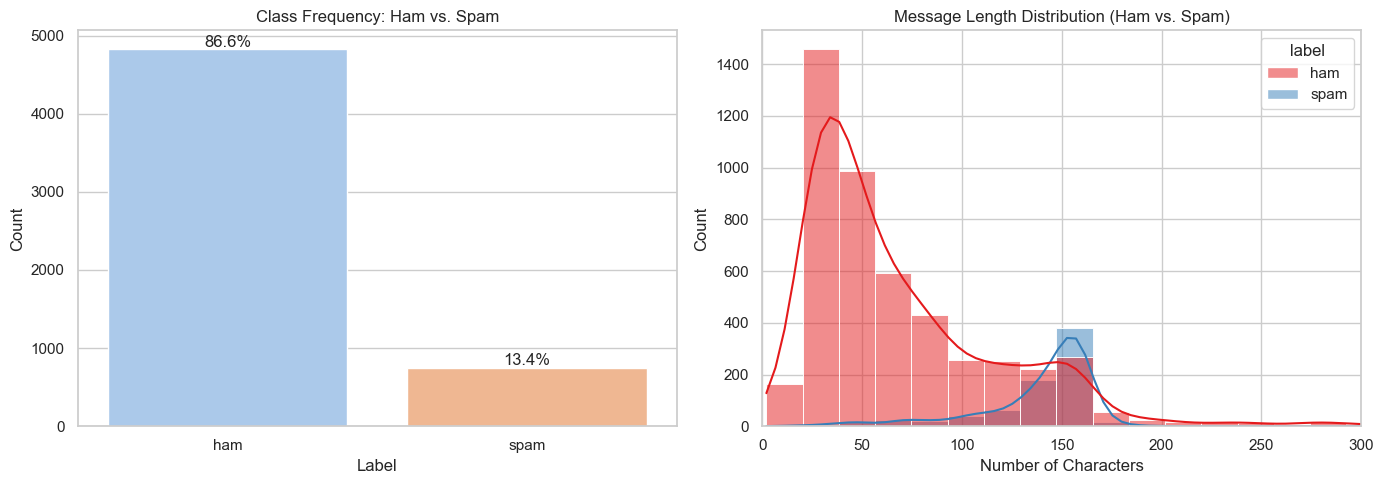

Text Length Summary by Category


label                         ham        spam
message_length count  4825.000000  747.000000
               mean     70.989637  138.824632
               std      58.010481   29.165701
               min       2.000000   13.000000
               25%      33.000000  132.500000
               50%      52.000000  149.000000
               75%      92.000000  157.000000
               max     910.000000  224.000000
word_count     count  4825.000000  747.000000
               mean     14.200622   23.851406
               std      11.424511    5.811898
               min       1.000000    2.000000
               25%       7.000000   22.000000
               50%      11.000000   25.000000
               75%      19.000000   28.000000
               max     171.000000   35.000000

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='label', palette='pastel', ax=axes[0])
axes[0].set_title("Class Frequency: Ham vs. Spam")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

total = len(df)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    axes[0].annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True, palette='Set1', ax=axes[1])
axes[1].set_title("Message Length Distribution (Ham vs. Spam)")
axes[1].set_xlabel("Number of Characters")
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()

print("Text Length Summary by Category")
display(df.groupby('label')[['message_length', 'word_count']].describe().T)

Vocabulary size: 3000
Training feature matrix shape: (4457, 3000)

Classification Performance Comparison


,Model,Accuracy,Precision (Spam),Recall (Spam),F1-Score (Spam)
0,Multinomial Naive Bayes,0.973094,0.98374,0.812081,0.889706
1,Logistic Regression,0.972197,1.00000,0.791946,0.883895


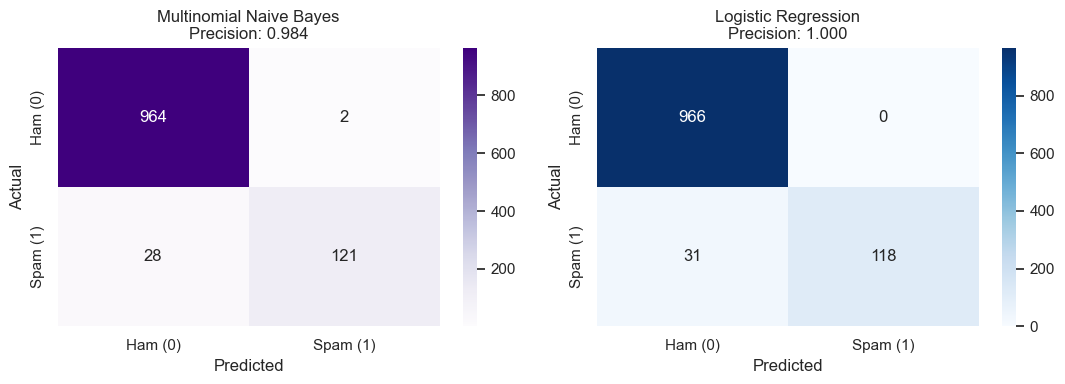

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

X = df['message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(stop_words='english', lowercase=True, max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Training feature matrix shape: {X_train_tfidf.shape}")

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

def get_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Spam)": precision_score(y_true, y_pred),
        "Recall (Spam)": recall_score(y_true, y_pred),
        "F1-Score (Spam)": f1_score(y_true, y_pred)
    }

metrics_summary = pd.DataFrame([
    get_metrics(y_test, y_pred_nb, "Multinomial Naive Bayes"),
    get_metrics(y_test, y_pred_lr, "Logistic Regression")
])

print("\nClassification Performance Comparison")
display(metrics_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Ham (0)', 'Spam (1)'], yticklabels=['Ham (0)', 'Spam (1)'], ax=axes[0])
axes[0].set_title(f"Multinomial Naive Bayes\nPrecision: {precision_score(y_test, y_pred_nb):.3f}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham (0)', 'Spam (1)'], yticklabels=['Ham (0)', 'Spam (1)'], ax=axes[1])
axes[1].set_title(f"Logistic Regression\nPrecision: {precision_score(y_test, y_pred_lr):.3f}")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [4]:
def predict_message(text, model=nb_model, vectorizer=tfidf):
    processed = vectorizer.transform([text])
    pred = model.predict(processed)[0]
    prob = model.predict_proba(processed)[0][pred]
    label = "SPAM" if pred == 1 else "HAM (Legitimate)"
    return label, prob

sample_messages = [
    "Hey, are we still meeting up for coffee tomorrow afternoon?",
    "URGENT! You have won a 1000 cash prize or a free holiday. Call 09050000321 to claim your reward now!",
    "Can you please review the attached report before Monday's presentation?",
    "Congratulations! You are selected for an exclusive credit loan with 0% interest. Click here to register."
]

print("Real-time Message Predictions")
for msg in sample_messages:
    label, confidence = predict_message(msg)
    print(f"\nMessage: \"{msg}\"")
    print(f"Classification: [{label}] (Confidence: {confidence*100:.2f}%)")

Real-time Message Predictions

Message: "Hey, are we still meeting up for coffee tomorrow afternoon?"
Classification: [HAM (Legitimate)] (Confidence: 99.22%)

Message: "URGENT! You have won a 1000 cash prize or a free holiday. Call 09050000321 to claim your reward now!"
Classification: [SPAM] (Confidence: 99.55%)

Message: "Can you please review the attached report before Monday's presentation?"
Classification: [HAM (Legitimate)] (Confidence: 86.49%)

Message: "Congratulations! You are selected for an exclusive credit loan with 0% interest. Click here to register."
Classification: [SPAM] (Confidence: 69.94%)
